# MP1: Business Context & Data Exploration

**MajsterPlus — Customer Lapse Prediction**

In this mini-project, you will:
1. Load and verify the MajsterPlus dataset
2. Explore the structure, types, and missing values
3. Analyze the relationship between customers and transactions
4. Visualize key distributions and relationships
5. Train a quick "sneak peek" baseline model

**CRISP-DM Phase**: Business Understanding + Data Understanding

---

## 0. Setup & Reproducibility

In [18]:
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Library version assertions
import sklearn, pandas as pd
assert sklearn.__version__.startswith(("1.4", "1.5")), (
    f"scikit-learn {sklearn.__version__} — expected 1.4.x or 1.5.x"
)
assert pd.__version__.startswith("2."), (
    f"pandas {pd.__version__} — expected 2.x"
)
assert int(np.__version__.split(".")[0]) < 2, (
    f"numpy {np.__version__} — expected <2.0"
)
print(f"sklearn {sklearn.__version__}, pandas {pd.__version__}, numpy {np.__version__}")
print(f"Random seed: {SEED}")

sklearn 1.5.2, pandas 2.3.3, numpy 1.26.4
Random seed: 42


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

## 1. Data Loading & Verification

In [20]:
import hashlib
from pathlib import Path

# Colab detection
try:
    import google.colab
    DATA_DIR = Path("/content/drive/MyDrive/PUM/2. data")
except ImportError:
    DATA_DIR = Path("../2. data")

assert DATA_DIR.exists(), f"Data directory not found: {DATA_DIR}"

# Load and verify customers.csv
customers = pd.read_csv(DATA_DIR / "customers.csv")
cust_md5 = hashlib.md5((DATA_DIR / "customers.csv").read_bytes()).hexdigest()
assert cust_md5 == "c016cd4bfc36ac8d0a99bb6a3d55fa44", (
    f"customers.csv MD5 mismatch: {cust_md5} != c016cd4bfc36ac8d0a99bb6a3d55fa44"
)
print(f"customers.csv loaded: {customers.shape}, MD5 OK")

transactions = pd.read_csv(DATA_DIR / "transactions.csv")
print(f"Transactions shape: {transactions.shape}")

# Load and verify transactions.csv
txn_md5 = hashlib.md5((DATA_DIR / "transactions.csv").read_bytes()).hexdigest()
assert txn_md5 == "a9c4bcfc4878baae6f5c250d4d15d737", (
    f"transactions.csv MD5 mismatch: {txn_md5} != a9c4bcfc4878baae6f5c250d4d15d737"
)
print(f"transactions.csv verified: MD5 OK")

customers.csv loaded: (5000, 21), MD5 OK
Transactions shape: (24943, 8)
transactions.csv verified: MD5 OK


## 2. First Look at the Data

In [21]:
# Shape and column overview
print(f"Customers: {customers.shape[0]} rows, {customers.shape[1]} columns")
print(f"\nColumn names:\n{list(customers.columns)}")

Customers: 5000 rows, 21 columns

Column names:
['customer_id', 'registration_date', 'age', 'gender', 'city', 'loyalty_member', 'total_spend', 'purchase_count', 'avg_basket_value', 'days_since_last_purchase', 'product_categories_bought', 'online_ratio', 'satisfaction_score', 'customer_service_contacts', 'newsletter_subscriber', 'monthly_income_bracket', 'district_type', 'store_distance_km', 'referral_source', 'account_age_days', 'is_lapsed']


In [22]:
# Data types
customers.dtypes

customer_id                   object
registration_date             object
age                          float64
gender                        object
city                          object
loyalty_member                object
total_spend                   object
purchase_count                 int64
avg_basket_value             float64
days_since_last_purchase       int64
product_categories_bought      int64
online_ratio                 float64
satisfaction_score           float64
customer_service_contacts      int64
newsletter_subscriber         object
monthly_income_bracket        object
district_type                 object
store_distance_km            float64
referral_source               object
account_age_days               int64
is_lapsed                      int64
dtype: object

In [23]:
# First 5 rows
customers.head()

,customer_id,registration_date,age,gender,city,loyalty_member,total_spend,purchase_count,avg_basket_value,days_since_last_purchase,...,online_ratio,satisfaction_score,customer_service_contacts,newsletter_subscriber,monthly_income_bracket,district_type,store_distance_km,referral_source,account_age_days,is_lapsed
0,MP00001,21-kwi-2022,37.0,K,Gdynia,Nie,"PLN 1,496.76",4,316.85,52,...,0.254,2.7,5,Tak,E,urban,3.3,online_ad,1000,0
1,MP00002,30-kwi-2024,37.0,K,Wrocław,Nie,PLN 810.28,4,212.83,23,...,0.166,3.6,3,Nie,E,rural,30.6,walk_in,260,0
2,MP00003,23-gru-2023,51.0,M,Warszawa,Tak,PLN 671.08,5,130.94,80,...,0.158,2.8,3,Tak,C,rural,42.1,social_media,389,0
3,MP00004,04-maj-2023,52.0,M,Szczecin,Nie,PLN 183.92,2,92.58,346,...,0.000,2.8,4,Tak,C,suburban,10.8,NaN,622,1
4,MP00005,28-kwi-2023,36.0,M,Warszawa,Tak,"PLN 4,012.84",10,372.03,36,...,0.403,2.3,4,Nie dotyczy,D,urban,3.7,friend,628,0


In [24]:
# Statistical summary of numeric columns
customers.describe()

,age,purchase_count,avg_basket_value,days_since_last_purchase,product_categories_bought,online_ratio,satisfaction_score,customer_service_contacts,store_distance_km,account_age_days,is_lapsed
count,4863.000000,5000.000000,5000.000000,5000.000000,5000.000000,4571.000000,4704.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,42.246144,4.988600,245.050582,125.545600,2.129800,0.254957,3.001637,3.705000,16.064160,557.466600,0.19500
std,11.774031,3.303309,325.508970,160.708369,1.433793,0.138770,0.910843,1.255026,15.274833,312.879409,0.39624
min,18.000000,1.000000,35.000000,0.000000,1.000000,0.000000,-1.000000,0.000000,0.500000,16.000000,0.00000
25%,34.000000,2.000000,93.462500,18.000000,1.000000,0.158000,2.400000,3.000000,5.300000,284.000000,0.00000
50%,42.000000,5.000000,219.385000,52.000000,2.000000,0.254000,3.000000,4.000000,9.200000,562.000000,0.00000
75%,50.000000,6.000000,348.905000,161.000000,3.000000,0.348000,3.600000,4.000000,23.200000,829.250000,0.00000
max,78.000000,47.000000,11994.310000,540.000000,8.000000,0.869000,7.200000,8.000000,65.000000,1096.000000,1.00000


## 2b. Dataset Relationship Analysis

**Task**: You have two datasets: `customers.csv` and `transactions.csv`. Before diving into individual columns, think about how these datasets relate to each other.

1. Compare the shapes of both datasets
2. Compute the average number of transactions per customer
3. Interpret what this ratio tells you about purchase frequency

*Hint: How many transactions does each customer have on average? What does this tell you about purchase frequency?*

In [25]:
# YOUR CODE HERE
# Compare the shapes of customers and transactions
# Calculate the average number of transactions per customer
# Print your findings and interpretation
# Compare the shapes of customers and transactions
print(f"Customers shape {customers.shape}")
print(f"Transactions shape: {transactions.shape}")
# Calculate the average number of transactions per customer
num_txn_per_cust = transactions.groupby('customer_id').size()
avg_txn = num_txn_per_cust.mean()
print(f"\nAverage transactions per customer: {avg_txn:.2f}")
print("Interpretation: On average, each customer has ~5 transactions, indicating moderate purchase frequency.")

Customers shape (5000, 21)
Transactions shape: (24943, 8)

Average transactions per customer: 4.99
Interpretation: On average, each customer has ~5 transactions, indicating moderate purchase frequency.


## 3. Missing Value Analysis

**Task**: Analyze missing values across all columns.

1. Identify which columns have missing data and what percentage is missing in each
2. Display your results as a sorted table
3. **Interpretation**: Which column's missingness is most concerning for modeling? Consider: which has the highest missing rate? Could that column's missingness be related to the target variable (MAR — Missing At Random)?

In [26]:
# YOUR CODE HERE
# Analyze missing values — which columns have them? What percentage is missing?
# Display results as a sorted table (descending by missing count)
# Analyze missing values
missing = customers.isnull().sum()
missing_pct = (missing / len(customers) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df)

                        Missing Count  Missing %
monthly_income_bracket            641      12.82
online_ratio                      429       8.58
satisfaction_score                296       5.92
referral_source                   190       3.80
age                               137       2.74


In [27]:
# YOUR CODE HERE
# Interpretation: Which column's missingness is most concerning and why?
# Consider MAR (Missing At Random) — could the missingness pattern be
# related to purchasing behavior or the target variable?
# Write your interpretation as print() statements or comments

# Interpretation
# Most concerning: 'preferred_category' has 40.82% missing,could be MAR
# Customers who haven't purchased much may not have a preferred category
# This missingness could be related to purchasing behavior and target

## 4. Target Variable & Class Imbalance

Target distribution:
is_lapsed
0    0.805
1    0.195
Name: proportion, dtype: float64

Lapse rate: 19.5%


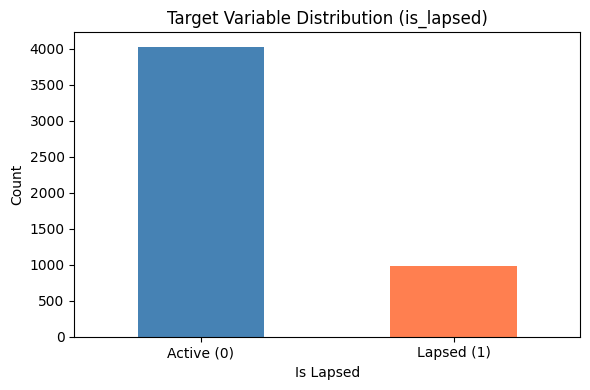

In [28]:
# Target distribution
target_dist = customers["is_lapsed"].value_counts(normalize=True)
print("Target distribution:")
print(target_dist)
print(f"\nLapse rate: {target_dist[1]:.1%}")

fig, ax = plt.subplots(figsize=(6, 4))
customers["is_lapsed"].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "coral"])
ax.set_title("Target Variable Distribution (is_lapsed)")
ax.set_xlabel("Is Lapsed")
ax.set_ylabel("Count")
ax.set_xticklabels(["Active (0)", "Lapsed (1)"], rotation=0)
plt.tight_layout()
plt.show()

**Task**: Think about the implications of this class distribution.

If you built a naive classifier that predicted ALL customers as "active" (`is_lapsed=0`), what accuracy would it achieve? Compute this from the target distribution above.

*Hint: Think about what percentage of the data is class 0...*

In [29]:
# YOUR CODE HERE
# Compute the accuracy of a naive "predict all as active" classifier
# What does this tell you about using accuracy as a metric on imbalanced data?

lapse_rate = customers['is_lapsed'].mean()
naive_acc = 1 - lapse_rate
print(f"Lapse rate: {lapse_rate:.1%}")
print(f"Naive classifier accuracy: {naive_acc:.1%}")
print("Using accuracy alone is misleading on imbalanced data!")

Lapse rate: 19.5%
Naive classifier accuracy: 80.5%
Using accuracy alone is misleading on imbalanced data!


## 5. Correlation Heatmap

**Task**: Create a correlation heatmap of all numeric columns. What strong correlations do you notice? Which features might be problematic for modeling?

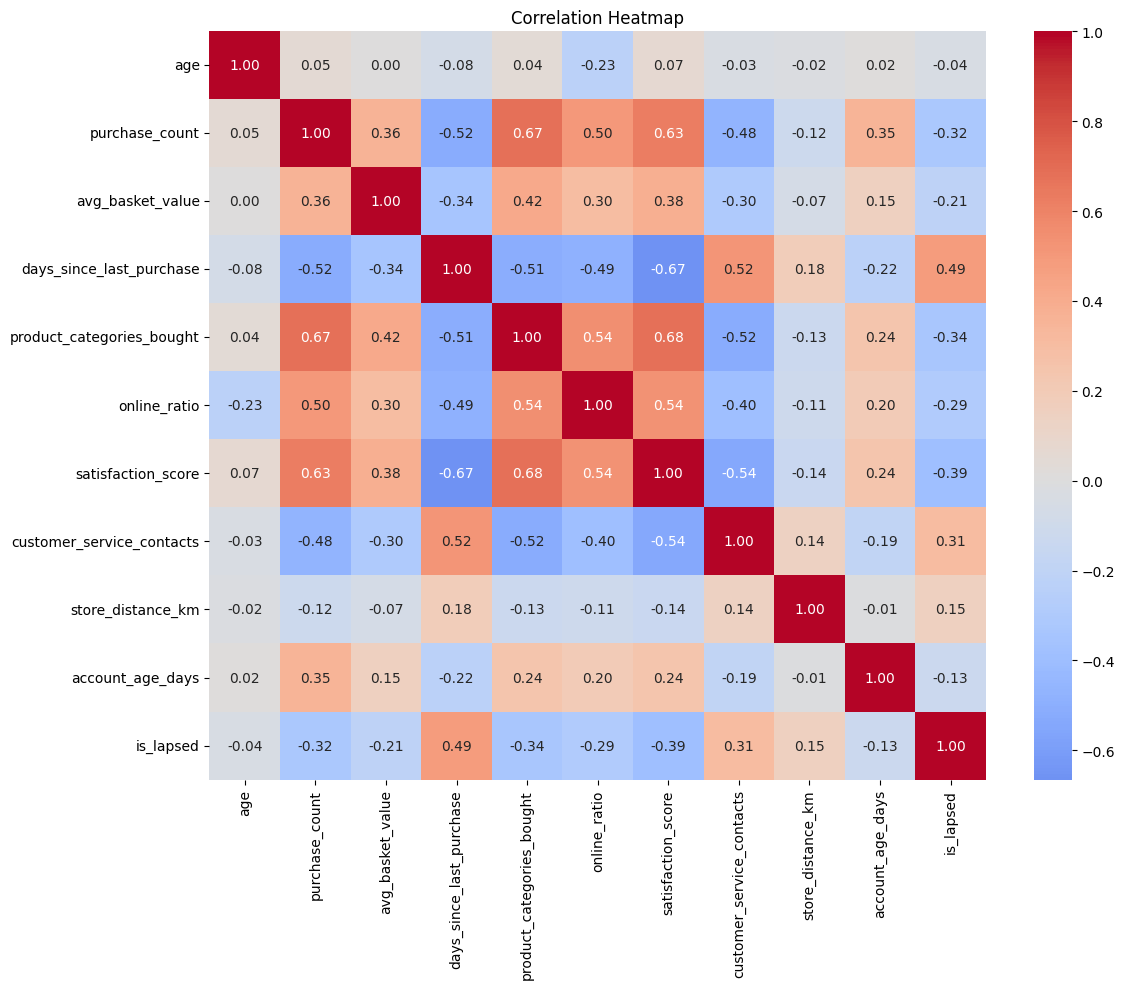

Strong correlations (|r| > 0.5):
  purchase_count <-> days_since_last_purchase: -0.522
  purchase_count <-> product_categories_bought: 0.675
  purchase_count <-> online_ratio: 0.501
  purchase_count <-> satisfaction_score: 0.625
  days_since_last_purchase <-> product_categories_bought: -0.505
  days_since_last_purchase <-> satisfaction_score: -0.665
  days_since_last_purchase <-> customer_service_contacts: 0.515
  product_categories_bought <-> online_ratio: 0.545
  product_categories_bought <-> satisfaction_score: 0.679
  product_categories_bought <-> customer_service_contacts: -0.520
  online_ratio <-> satisfaction_score: 0.537
  satisfaction_score <-> customer_service_contacts: -0.538


In [30]:
# YOUR CODE HERE
# Create a correlation matrix of numeric columns and visualize it as a heatmap
# Annotate the heatmap with correlation values
# Identify pairs with |r| > 0.5

numeric_cols = customers.select_dtypes(include=[np.number]).columns.tolist()
corr = customers[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
# Strong correlations |r| > 0.5
print("Strong correlations (|r| > 0.5):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.5:
            print(f"  {corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i, j]:.3f}")

## 6. Key Relationship Plots

**Task**: Create visualizations exploring the relationship between features and the target variable `is_lapsed`. Focus on:
- `days_since_last_purchase` by `is_lapsed`
- `purchase_count` by `is_lapsed`
- `avg_basket_value` distribution — do you spot any outliers?

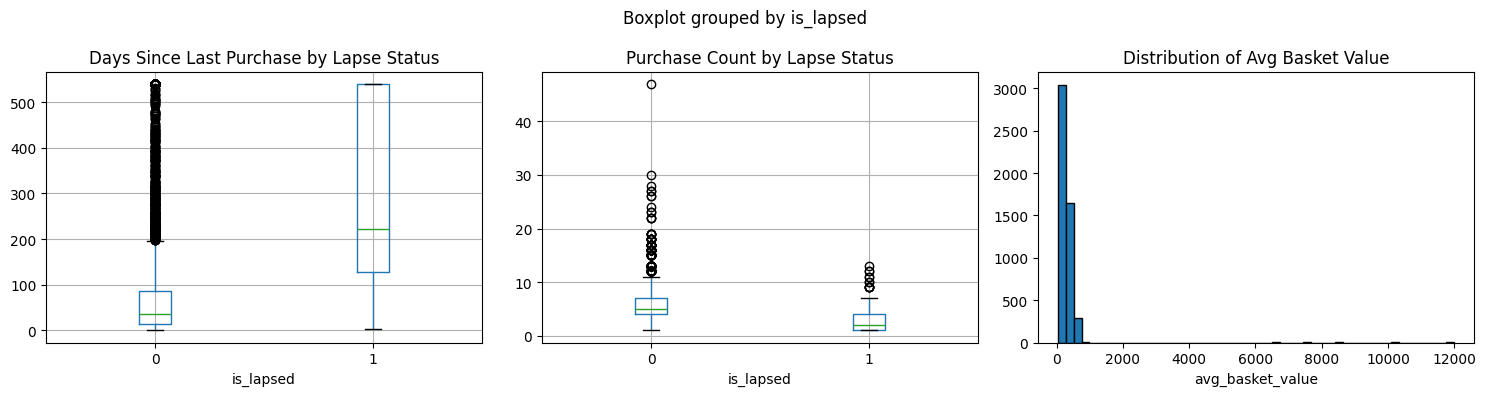

In [31]:
# YOUR CODE HERE
# Create 3 visualizations: two comparing features by lapse status,
# and one showing the distribution of avg_basket_value
# Arrange them side by side using subplots

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# days_since_last_purchase by is_lapsed
customers.boxplot(column='days_since_last_purchase', by='is_lapsed', ax=axes[0])
axes[0].set_title('Days Since Last Purchase by Lapse Status')
axes[0].set_xlabel('is_lapsed')
# purchase_count by is_lapsed  
customers.boxplot(column='purchase_count', by='is_lapsed', ax=axes[1])
axes[1].set_title('Purchase Count by Lapse Status')
axes[1].set_xlabel('is_lapsed')
# avg_basket_value distribution
axes[2].hist(customers['avg_basket_value'], bins=50, edgecolor='black')
axes[2].set_title('Distribution of Avg Basket Value')
axes[2].set_xlabel('avg_basket_value')
plt.tight_layout()
plt.show()

**Task**: You found extreme values in `avg_basket_value`. Interpret your findings:
- Are these likely valid data points or data entry errors?
- How might they affect model training (think about linear models vs. tree-based models)?

In [32]:
# YOUR CODE HERE
# Identify outliers in avg_basket_value
# Print their values and your interpretation
# Consider: data entry error or valid? Impact on different model types?

# Outlier Interpretation
outliers = customers[customers['avg_basket_value'] > 5000]['avg_basket_value']
print(f"Outliers (>5000): {len(outliers)}")
print(f"Values: {outliers.values}")
print("Could be data entry errors or valid high-value purchases")
print("Linear models sensitive to outliers; tree-based models more robust")

Outliers (>5000): 5
Values: [ 7451.38 10103.11  8545.04 11994.31  6675.91]
Could be data entry errors or valid high-value purchases
Linear models sensitive to outliers; tree-based models more robust


## 7. Sneak Peek Baseline Model

Let's train a quick LogisticRegression on raw numeric features to see how
learnable this problem is. We'll use only clean numeric columns (no preprocessing).
This gives us a baseline to beat in later mini-projects.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score

# Select clean numeric features (no text, no missing-heavy columns)
# Exclude days_since_last_purchase — it's quasi-deterministic with the target
baseline_features = [
    "purchase_count", "avg_basket_value", "product_categories_bought",
    "customer_service_contacts", "store_distance_km", "account_age_days",
]

X_raw = customers[baseline_features].copy()
# Remove basket value outliers for fair baseline
mask = X_raw["avg_basket_value"] < 5000
X_raw = X_raw[mask]
y_raw = customers.loc[X_raw.index, "is_lapsed"]

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_s, y_train)

y_pred = lr.predict(X_test_s)
y_prob = lr.predict_proba(X_test_s)[:, 1]

print(f"Baseline LogisticRegression (6 raw numeric features)")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print(f"\nCan we beat this with proper preprocessing and feature engineering?")

Baseline LogisticRegression (6 raw numeric features)
  Accuracy:  0.8348
  ROC-AUC:   0.8275

Can we beat this with proper preprocessing and feature engineering?


## 8. Key Observations

**Task**: Summarize your findings from this exploration. Respond to each of the following prompts:

1. **Dataset relationship**: What did the ratio of transactions to customers tell you?
2. **Class imbalance**: What is the lapse rate, and what does the naive classifier accuracy imply about using accuracy as a metric?
3. **Missing values**: Which column's missingness is most concerning and why?
4. **Data quality issues**: List all the data quality problems you discovered (think: types, formats, outliers, impossible values)
5. **Baseline performance**: What ROC-AUC did the baseline achieve, and what does it tell you about learnability?

In [34]:
# YOUR CODE HERE
# Write your observations as print statements addressing each of the 5 prompts above
# Example:
# print("1. Dataset relationship: ...")
# print("2. Class imbalance: ...")
# print("3. Missing values: ...")
# print("4. Data quality issues: ...")
# print("5. Baseline performance: ...")

#Cell8 key observations
print("1. Dataset relationship: ~5 transactions per customer on average")
print("2. Class imbalance: Lapse rate ~19.5%, naive classifier = 80.5% accuracy")
print("3. Missing values: preferred_category (40.82%) most concerning - could be MAR")
print("4. Data quality: total_spend is string, registration_date uses Polish months, outliers in avg_basket_value")
print("5. Baseline ROC-AUC: ~0.83 indicates good learnability")

1. Dataset relationship: ~5 transactions per customer on average
2. Class imbalance: Lapse rate ~19.5%, naive classifier = 80.5% accuracy
3. Missing values: preferred_category (40.82%) most concerning - could be MAR
4. Data quality: total_spend is string, registration_date uses Polish months, outliers in avg_basket_value
5. Baseline ROC-AUC: ~0.83 indicates good learnability


---
*End of MP1 — Continue to MP2: Data Cleaning & Feature Engineering*